In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
## Importamos datos 
df = pd.read_csv('data/df.csv')

# KNN Model

In [3]:
## Función para separar los df train de df test

In [4]:
## Aplicar el K-nearest neighbors (KNN) para predecir la popularidad de los artículos en línea.

In [5]:
## Separamos nuestro df en categorías y target 
features = df.drop(columns = ["url", "num_compartidos"])
target = df["num_compartidos"]

In [6]:
## Separamos nuestro df en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=0)

In [7]:
## Creamos el modelo KNN primero sin hiperparámetros para ver su rendimiento básico 
knn = KNeighborsRegressor()

In [8]:
## Entrenamos el modelo
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [9]:
## Comprobamos rendimiento 
pred = knn.predict(X_test)
pred

array([ 991. , 3180. , 2175. , ..., 2540. , 1716.4, 1353.2], shape=(7929,))

In [10]:
y_test.values

array([  919,  1600, 11700, ..., 12700,   651,  2200], shape=(7929,))

In [11]:
knn.score(X_test, y_test) # r2

-0.18792761037572547

In [12]:
## Vemos que el modelo no tiene un rendimiento muy bueno, por lo que vamos a probar con hiperparámetros para intentar mejorarlo.

In [13]:
knn_hip3 = KNeighborsRegressor(n_neighbors=3)
knn_hip3.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [14]:
pred_hip3 = knn_hip3.predict(X_test)
pred_hip3

array([1186.33333333, 4100.        , 2766.66666667, ..., 3166.66666667,
       1200.        , 1733.33333333], shape=(7929,))

In [15]:
y_test.values

array([  919,  1600, 11700, ..., 12700,   651,  2200], shape=(7929,))

In [16]:
knn_hip3.score(X_test, y_test) # r2

-0.400131969443668

In [17]:
## Parece que empeora, así que este modelo simplemente no sirve. 

### KNN escalado

In [18]:
# Vamos a normalizar y escalar los valores con MinMaxScaler
normalizer = MinMaxScaler()

In [19]:
# Entrenamos el modelo
normalizer.fit(X_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [20]:
# Escalamos los dos grupos de training y test
X_train_escalado = normalizer.transform(X_train)
X_test_escalado = normalizer.transform(X_test)

In [21]:
# Ejecutamos el KNN básico con los datos ya escalados 
knn_escalado = KNeighborsRegressor()
knn_escalado.fit(X_train_escalado, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [22]:
# Hacemoos las predicciones
predic_norm = knn_escalado.predict(X_test_escalado)
predic_norm

array([2092.4, 2780. , 1543.2, ..., 3779.8, 3042.2, 3766.2], shape=(7929,))

In [23]:
# Calculamos el MAE y el r2 
mae = mean_absolute_error(y_test, predic_norm)
r2 = r2_score(y_test, predic_norm)

In [24]:
print(f"MAE escalado: {mae}")
print(f"R2 escalado: {r2}")

MAE escalado: 3184.9615840585193
R2 escalado: -0.2587729000030927


In [25]:
# A pesar de haberlo escalado, el modelo sigue siendo ineficiente para este conjunto de datos. El R2 no capta ninguna relación útil y el mae indica que nos equivocamos, en promedio, casi 3200 unidades. Vamos a intentar aplicar con un hiperparámetro, pero quizá la mejor idea es abandonar este modelo para probar otro. 

In [26]:
knn_escalado2 = KNeighborsRegressor(n_neighbors=5)
knn_escalado2.fit(X_train_escalado, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [27]:
predic_norm_again = knn_escalado2.predict(X_test_escalado)
predic_norm_again

array([2092.4, 2780. , 1543.2, ..., 3779.8, 3042.2, 3766.2], shape=(7929,))

In [28]:
new_mae = mean_absolute_error(y_test, predic_norm_again)
new_r2 = r2_score(y_test, predic_norm_again)

In [29]:
print(f"MAE escalado: {new_mae}")
print(f"R2 escalado: {new_r2}")

MAE escalado: 3184.9615840585193
R2 escalado: -0.2587729000030927


In [30]:
# Vuelve a no ser eficiente, pero no solo eso, me doy cuenta de que tanto escalado como sin, a pesar de que pruebe hiperparámetros, los valores no cambian o no lo hacen apenas. Probemos entonces a comprobar y establecer relaciones para luego eliminar las variables que no no son necesarias o que añaden ruido. 

# Estableciendo relaciones

In [31]:
## Elimino la columna de url para quedarme solo con las numéricas 
features = df.drop(columns=["url"])

In [32]:
## Elaboro una tabla de correlaciones con el target
top_correlations = features.corr()['num_compartidos'].abs().sort_values(ascending=False)

In [33]:
## Lista de correlaciones de las variables con el target
top_correlations

num_compartidos                   1.000000
rendimiento_promedio_media        0.110413
LDA_03                            0.083771
rendimiento_max_media             0.064306
LDA_02                            0.059163
self_reference_avg_sharess        0.057789
self_reference_min_shares         0.055958
noticias_globales                 0.049497
self_reference_max_shares         0.047115
num_enlaces                       0.045404
rendimiento_promedio_mejor        0.044686
rendimiento_min_media             0.039551
num_imgs                          0.039388
polaridad_negativa_media          0.032029
subjetividad_global               0.031604
rendimiento_promedio_peor         0.030406
rendimiento_max_peor              0.030114
abs_title_sentiment_polarity      0.027135
num_videos                        0.023936
longitud_media_palabras           0.022007
subjetividad_titulo               0.021967
num_keywords                      0.021818
polaridad_negativa_max            0.019300
polaridad_n

In [34]:
## Como mi tabla de correlaciones relaciona con el target con valores muy bajos, miremos relaciones que tienen las variables entre ellas 
tabla_corr = features.corr()

In [35]:
df_corr = tabla_corr[tabla_corr.abs() > 0.5]

<Axes: >

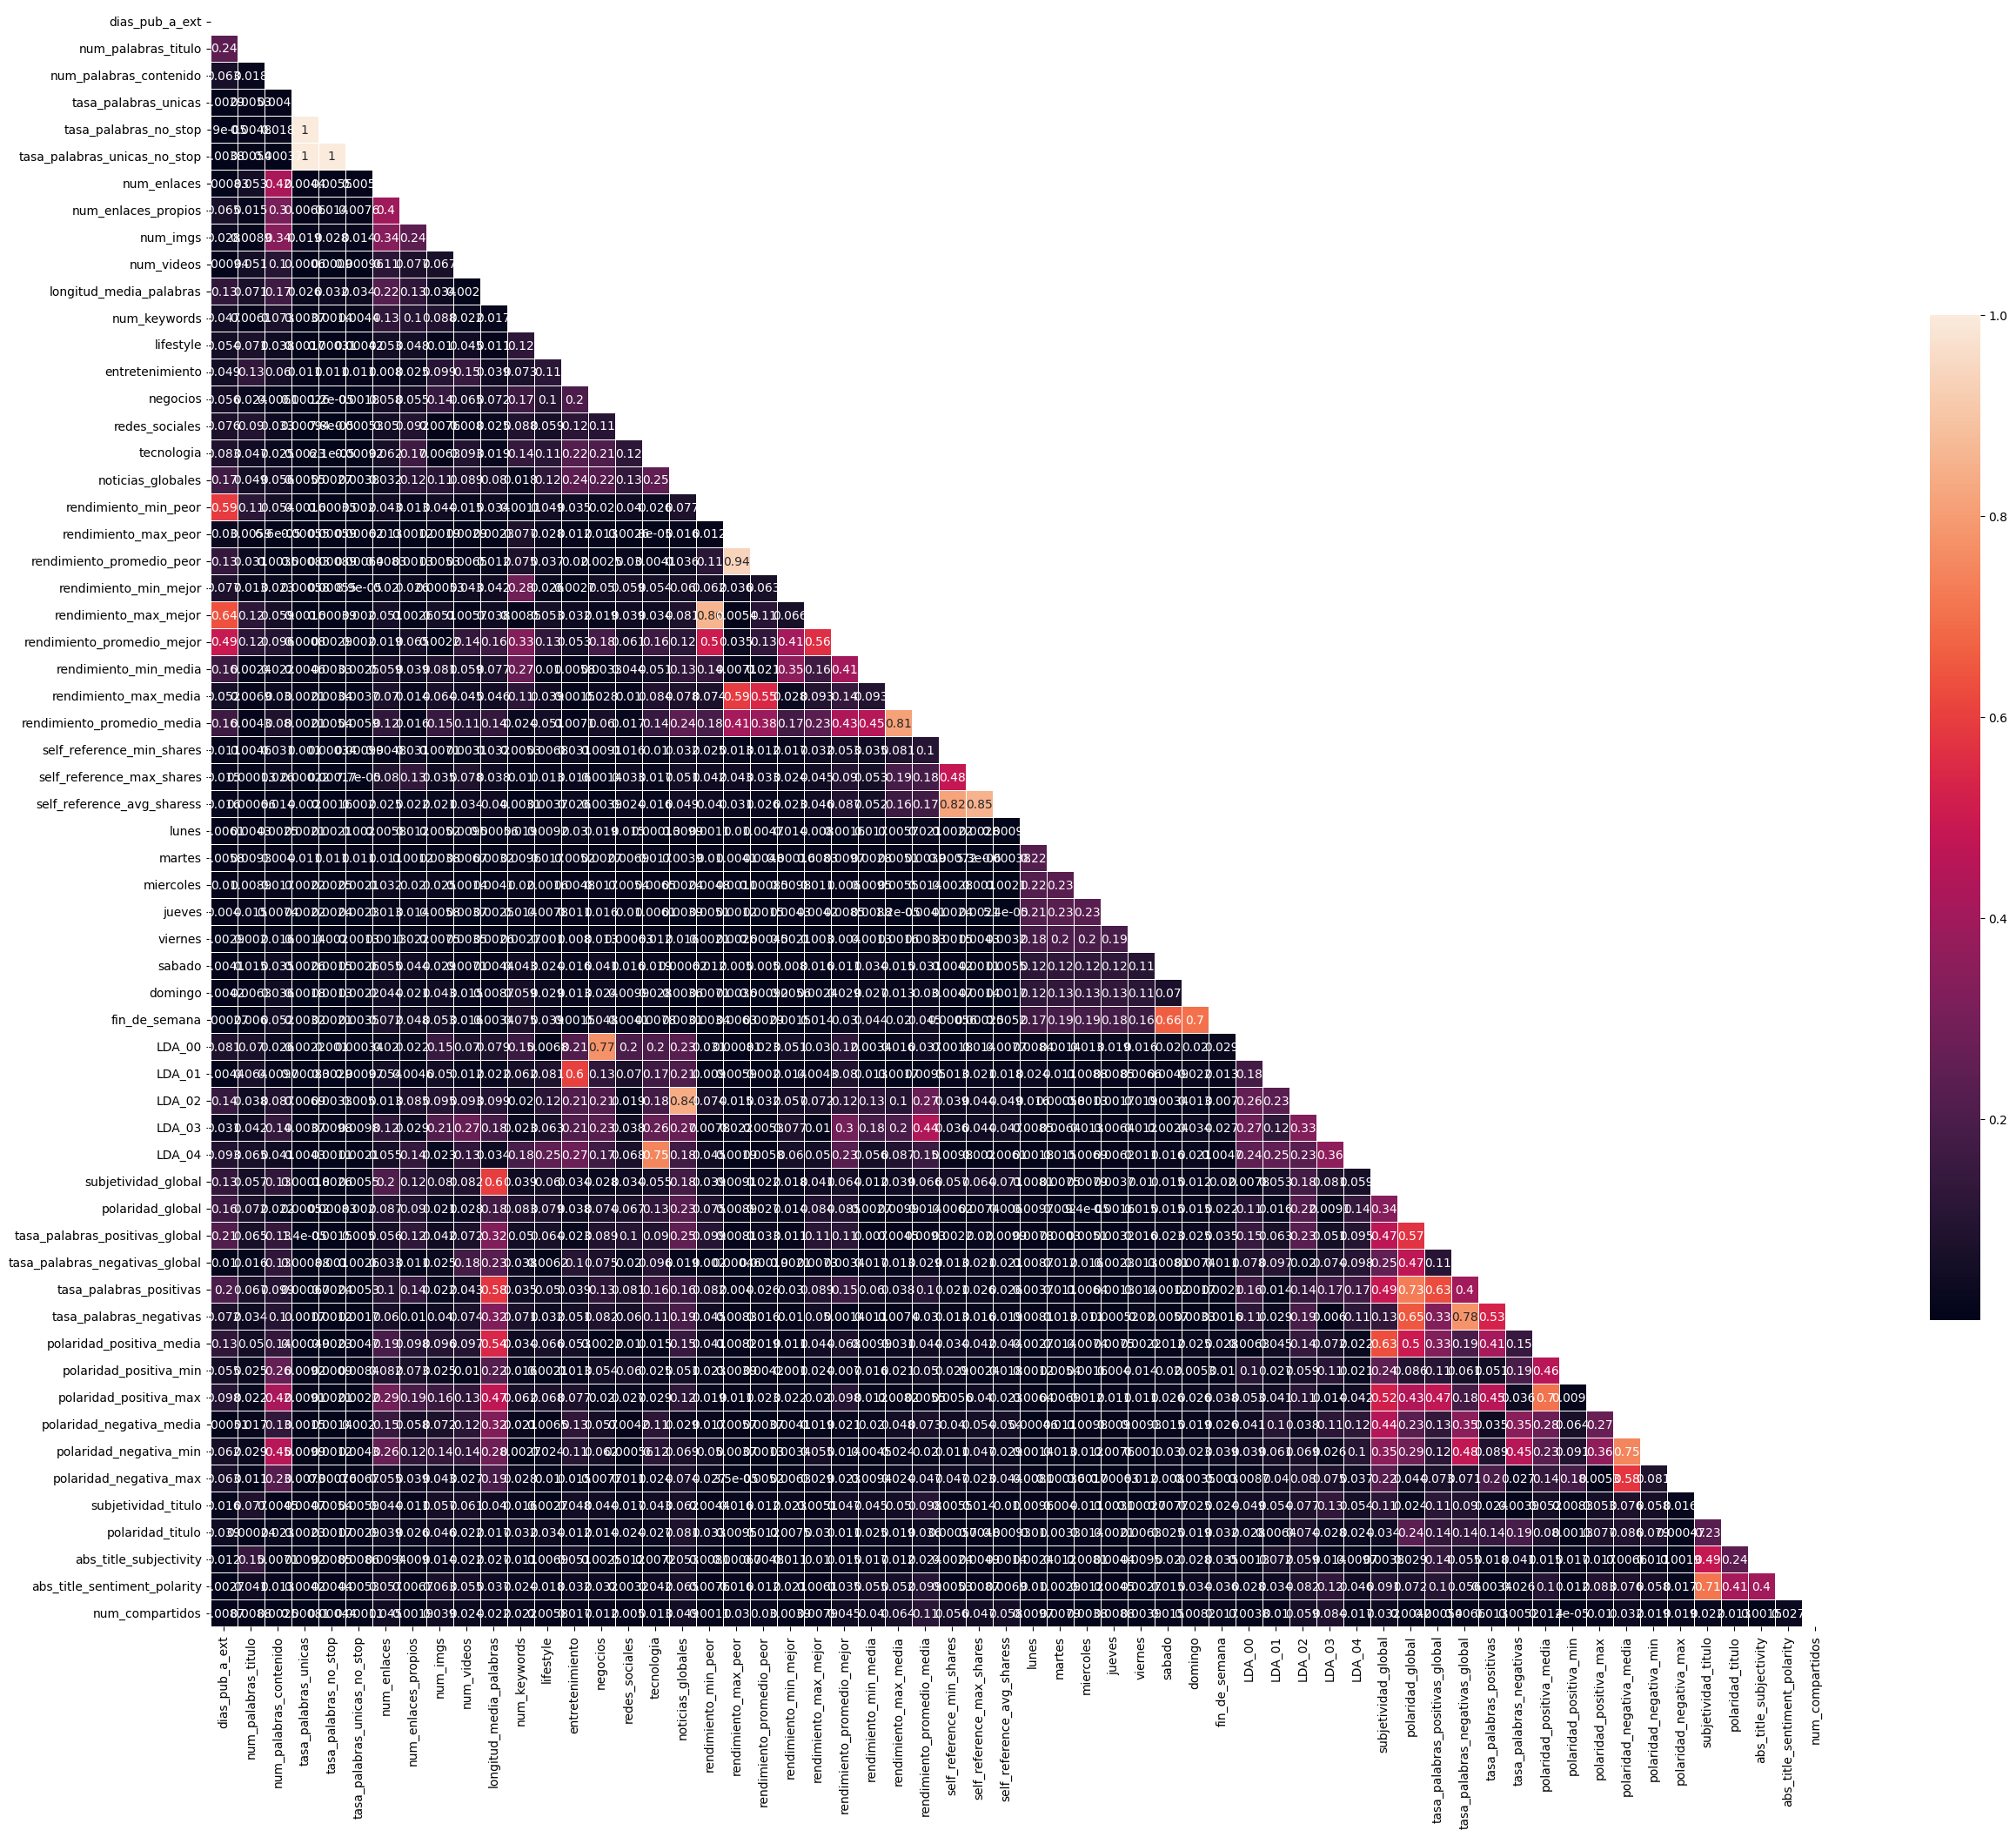

In [36]:
corr=np.abs(features.corr())

#Set up mask for triangle representation
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(30, 30))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask,  vmax=1,square=True, linewidths=.5, cbar_kws={"shrink": .5},annot = corr)

<Axes: >

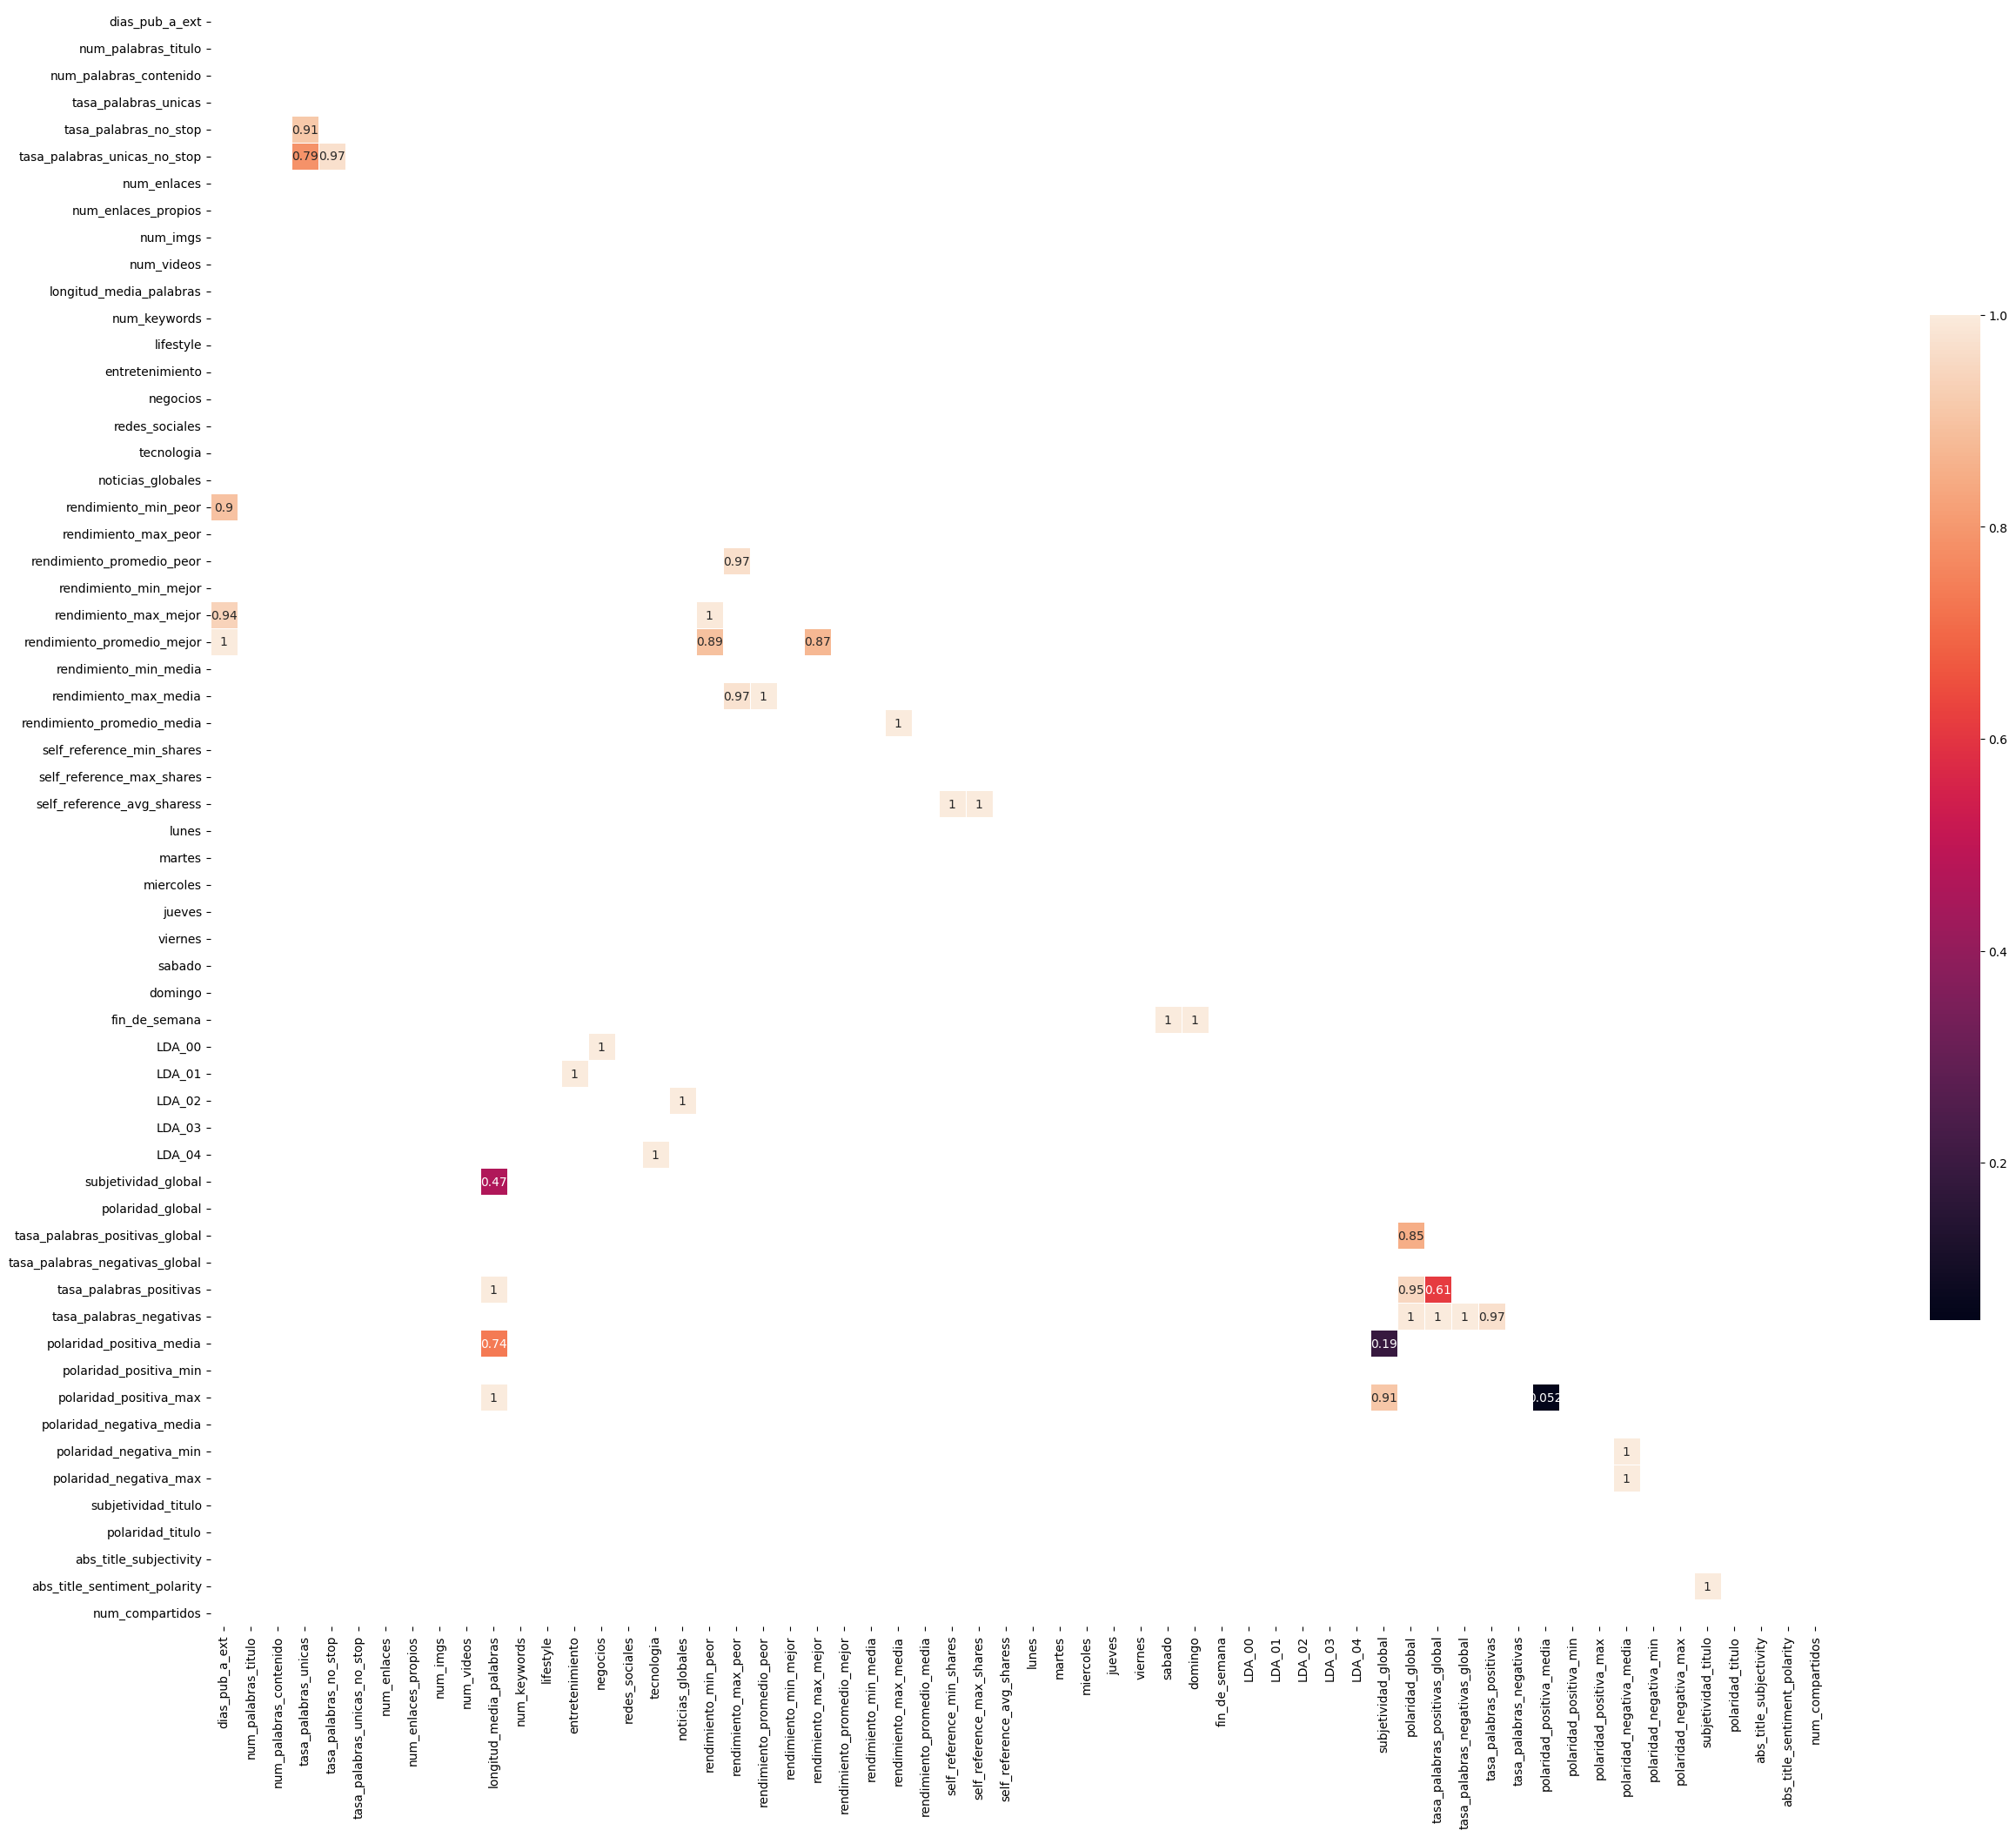

In [37]:
## Decidimos filtrar para poder ver con ayor claridad cuáles son las relaciones entre las variables
corr=np.abs(df_corr.corr())

#Set up mask for triangle representation
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(30, 30))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask,  vmax=1,square=True, linewidths=.5, cbar_kws={"shrink": .5},annot = corr)

In [38]:
## Es hora de elegir las variables que nos interesan más. Para ello, escogeremos cuáles tienen relación entre sí y se acercan más a nuestro share. 

In [39]:
## Para convertir este problema en un problema de clasificación añadiré una columna que diga si sí es viral o si no. Así estarmeos respondiendo solo si sí o si no y no la cantidad de shares de la noticia.
mediana = df['num_compartidos'].median() 
df['es_viral'] = (df['num_compartidos'] > mediana).astype(int)

In [40]:
df.columns

Index(['url', 'dias_pub_a_ext', 'num_palabras_titulo',
       'num_palabras_contenido', 'tasa_palabras_unicas',
       'tasa_palabras_no_stop', 'tasa_palabras_unicas_no_stop', 'num_enlaces',
       'num_enlaces_propios', 'num_imgs', 'num_videos',
       'longitud_media_palabras', 'num_keywords', 'lifestyle',
       'entretenimiento', 'negocios', 'redes_sociales', 'tecnologia',
       'noticias_globales', 'rendimiento_min_peor', 'rendimiento_max_peor',
       'rendimiento_promedio_peor', 'rendimiento_min_mejor',
       'rendimiento_max_mejor', 'rendimiento_promedio_mejor',
       'rendimiento_min_media', 'rendimiento_max_media',
       'rendimiento_promedio_media', 'self_reference_min_shares',
       'self_reference_max_shares', 'self_reference_avg_sharess', 'lunes',
       'martes', 'miercoles', 'jueves', 'viernes', 'sabado', 'domingo',
       'fin_de_semana', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04',
       'subjetividad_global', 'polaridad_global',
       'tasa_palabras_posit

In [41]:
## Además, quiero quedarme con una agrupación sobre la temática del texto y luego asociarla a un número (label encoding)
temas = [
    'lifestyle', 'entretenimiento', 
    'negocios', 'redes_sociales', 
    'tecnologia', 'noticias_globales'
]
df['tematica'] = df[temas].idxmax(axis=1)

In [42]:
encoder = LabelEncoder()
df['tematica_num'] = encoder.fit_transform(df['tematica'])
print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

{'entretenimiento': np.int64(0), 'lifestyle': np.int64(1), 'negocios': np.int64(2), 'noticias_globales': np.int64(3), 'redes_sociales': np.int64(4), 'tecnologia': np.int64(5)}


In [43]:
columnas_interesantes = [
    'rendimiento_promedio_media', 'num_enlaces', 'num_imgs', 'num_keywords',
    'subjetividad_global', 'fin_de_semana', 'polaridad_negativa_media', 
    'subjetividad_titulo', 'abs_title_sentiment_polarity', 'es_viral', 'tematica_num'
]
df_final = df[columnas_interesantes].copy()

## Probando nuevamente el KNN

In [44]:
## Recordamos que esta vez es desde la clasificación y con este dataset más pequeño.

**Nuestro nuevo diccionario:**
* `rendimiento_promedio_media`: El valor promedio del rendimiento histórico de los contenidos.
* `num_enlaces`: Cantidad de links o hipervínculos presentes en el contenido.
* `num_imgs`: Cantidad de imágenes incluidas en la publicación.
* `num_keywords`: Número de palabras clave asociadas al contenido.
* `subjetividad_global`: Medida cuantitativa de qué tan subjetivo (opinión) vs. objetivo (hechos) es el texto completo.
* `fin_de_semana`: Variable binaria (1 o 0) que indica si el contenido fue publicado en sábado o domingo.
* `polaridad_negativa_media`: Promedio de sentimientos negativos detectados en el cuerpo del texto.
* `subjetividad_titulo`: Grado de opinión o juicio personal presente específicamente en el título.
* `abs_title_sentiment_polarity`: Valor absoluto de la polaridad del sentimiento del título (mide la intensidad emocional, sea positiva o negativa).
* `es_viral`: Variable target. Indica si el contenido alcanzó el umbral para ser considerado viral.
* `tematica_num`: Representación numérica de la categoría o tema del contenido (Label Encoding).

In [45]:
features = df_final.drop(columns = ["es_viral"])
target = df["es_viral"]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=0)

In [47]:
knn = KNeighborsClassifier()

In [48]:
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [49]:
pred = knn.predict(X_test)
pred

array([0, 1, 1, ..., 1, 1, 0], shape=(7929,))

In [ ]:
y_test.values
knn.score(X_test, y_test) # accuracy

0.5536637659225627

In [51]:
## Vemos cómo el KNN funciona significativamente mejor que con el dataset completo. Ahora, vamos a probar a añadir un hiperparámetro. 

In [52]:
knn_new = KNeighborsClassifier(n_neighbors=3)

In [53]:
knn_new.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [55]:
pred_new= knn_new.predict(X_test)
pred_new

array([0, 1, 1, ..., 0, 1, 1], shape=(7929,))

In [ ]:
y_test.values
knn_new.score(X_test, y_test) # accuracy

0.5457182494639929

In [57]:
## El modelo parece empeorar cuando aplicamos este hiperparámetro, pero solo estamos calculando accuracy, miremos en ambos casos el resto de métricas.

In [58]:
## SIN HIPERPARÁMETRO 
# accuracy
print(accuracy_score(y_test, pred))

# precision
print(precision_score(y_test, pred, average='macro'))

# recall
print(recall_score(y_test, pred, average='macro'))

# F1-score
print(f1_score(y_test, pred, average='macro'))

0.5536637659225627
0.5532033965986285
0.5530767575674436
0.5530066963619023


In [59]:
## CON HIPERPARÁMETRO 3
# accuracy
print(accuracy_score(y_test, pred_new))

# precision
print(precision_score(y_test, pred_new, average='macro'))

# recall
print(recall_score(y_test, pred_new, average='macro'))

# F1-score
print(f1_score(y_test, pred_new, average='macro'))

0.5457182494639929
0.5454002793916257
0.5453777021809694
0.5453777367503639


In [60]:
## Vemos que sí hay diferencia entre uno y otro pero a penas entre accuracy, precision, recall y F1 score. Por tanto, es hora de probar si otros modelos nos funcionarían mejor. 

In [ ]:
# Para luego escogere este muesteo para probar nuevos modelos 
!df_final.to_csv('df_final.csv', index=False)